# 03b — Basic cohort plots

This notebook summarizes the initially available TCGA-LUAD cohort before the final filtering steps used for mutational-signature analyses and supervised modelling.

It:
- loads the clinical table and the exposure table separately,
- uses age and sex from the clinical table,
- uses tobacco smoking status from the exposure table,
- keeps missing/unknown smoking status visible,
- saves all plots into `plots/clinical_distributions`.


## 1. Imports and helper function

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)


def map_smoking_label(value):
    value = str(value).strip().lower()

    if value in ["", "nan", "not reported", "unknown", "--"]:
        return "Unknown"
    elif "never" in value or "lifelong" in value or "non-smoker" in value or "nonsmoker" in value:
        return "Never"
    elif "current smoker" in value and "reformed" not in value:
        return "Current"
    elif "former" in value or "reformed" in value or "current reformed" in value:
        return "Former"
    else:
        return "Unknown"

## 2. Define paths

In [2]:
clinical_path = PROJECT_ROOT / "data" / "clinical.tsv"
exposure_path = PROJECT_ROOT / "data" / "exposure.tsv"

plots_dir = PROJECT_ROOT / "plots"
clinical_plots_dir = plots_dir / "clinical_distributions"

clinical_plots_dir.mkdir(parents=True, exist_ok=True)


## 3. Load clinical and exposure data

The basic cohort plots are created from the initially available clinical and exposure files.  
Age and sex are taken from the clinical table, while smoking status is taken from the exposure table.


In [3]:
clinical_df = pd.read_csv(clinical_path, sep="\t")
exposure_df = pd.read_csv(exposure_path, sep="\t")

print("Clinical data preview:")
display(clinical_df.head())

print("Exposure data preview:")
display(exposure_df.head())


Clinical data preview:


,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,demographic.age_at_index,demographic.age_is_obfuscated,demographic.cause_of_death,demographic.cause_of_death_source,demographic.country_of_birth,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,demographic.education_level,demographic.ethnicity,demographic.gender,demographic.marital_status,demographic.occupation_duration_years,demographic.population_group,demographic.premature_at_birth,demographic.race,demographic.submitter_id,demographic.vital_status,demographic.weeks_gestation_at_birth,demographic.year_of_birth,demographic.year_of_death,diagnoses.adrenal_hormone,diagnoses.age_at_diagnosis,diagnoses.ajcc_clinical_m,diagnoses.ajcc_clinical_n,diagnoses.ajcc_clinical_stage,diagnoses.ajcc_clinical_t,diagnoses.ajcc_pathologic_m,diagnoses.ajcc_pathologic_n,diagnoses.ajcc_pathologic_stage,diagnoses.ajcc_pathologic_t,diagnoses.ajcc_serum_tumor_markers,diagnoses.ajcc_staging_system_edition,diagnoses.ann_arbor_b_symptoms,diagnoses.ann_arbor_b_symptoms_described,diagnoses.ann_arbor_clinical_stage,diagnoses.ann_arbor_extranodal_involvement,diagnoses.ann_arbor_pathologic_stage,diagnoses.best_overall_response,diagnoses.burkitt_lymphoma_clinical_variant,diagnoses.calgb_risk_group,diagnoses.cancer_detection_method,diagnoses.child_pugh_classification,diagnoses.clark_level,diagnoses.classification_of_tumor,diagnoses.cog_liver_stage,diagnoses.cog_neuroblastoma_risk_group,diagnoses.cog_renal_stage,diagnoses.cog_rhabdomyosarcoma_risk_group,...,diagnoses.uicc_clinical_stage,diagnoses.uicc_clinical_t,diagnoses.uicc_pathologic_m,diagnoses.uicc_pathologic_n,diagnoses.uicc_pathologic_stage,diagnoses.uicc_pathologic_t,diagnoses.uicc_staging_system_edition,diagnoses.ulceration_indicator,diagnoses.weiss_assessment_findings,diagnoses.weiss_assessment_score,diagnoses.who_cns_grade,diagnoses.who_nte_grade,diagnoses.wilms_tumor_histologic_subtype,diagnoses.year_of_diagnosis,treatments.chemo_concurrent_to_radiation,treatments.clinical_trial_indicator,treatments.course_number,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.drug_category,treatments.embolic_agent,treatments.initial_disease_status,treatments.lesions_treated_number,treatments.margin_distance,treatments.margin_status,treatments.margins_involved_site,treatments.number_of_cycles,treatments.number_of_fractions,treatments.prescribed_dose,treatments.prescribed_dose_units,treatments.pretreatment,treatments.protocol_identifier,treatments.radiosensitizing_agent,treatments.reason_treatment_ended,treatments.reason_treatment_not_given,treatments.regimen_or_line_of_therapy,treatments.residual_disease,treatments.route_of_administration,treatments.submitter_id,treatments.therapeutic_agents,treatments.therapeutic_level_achieved,treatments.therapeutic_levels_achieved,treatments.therapeutic_target_level,treatments.timepoint_category,treatments.treatment_anatomic_site,treatments.treatment_anatomic_sites,treatments.treatment_arm,treatments.treatment_dose,treatments.treatment_dose_max,treatments.treatment_dose_units,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-LUAD,0075437e-ba1a-46be-86d6-9773209a2b5e,Informed Consent,0,'--,Adenomas and Adenocarcinomas,Diagnosis,No,Bronchus and lung,TCGA-62-A471,64,false,'--,'--,'--,Germany,-23689,'--,407caae1-7c07-52e1-bca7-1e60cac760eb,'--,not hispanic or latino,male,'--,'--,'--,'--,white,TCGA-62-A471_demographic,Alive,'--,'--,'--,'--,23689,'--,'--,'--,'--,M0,N1,Stage IIB,T2b,'--,7th,'--,'--,'--,'--,'--,'--,'--,'

Exposure data preview:


,project.project_id,cases.case_id,cases.submitter_id,exposures.age_at_last_exposure,exposures.age_at_onset,exposures.alcohol_days_per_week,exposures.alcohol_drinks_per_day,exposures.alcohol_frequency,exposures.alcohol_history,exposures.alcohol_intensity,exposures.alcohol_type,exposures.asbestos_exposure,exposures.asbestos_exposure_type,exposures.chemical_exposure_type,exposures.cigarettes_per_day,exposures.coal_dust_exposure,exposures.environmental_tobacco_smoke_exposure,exposures.exposure_duration,exposures.exposure_duration_hrs_per_day,exposures.exposure_duration_years,exposures.exposure_id,exposures.exposure_source,exposures.exposure_type,exposures.occupation_duration_years,exposures.occupation_type,exposures.pack_years_smoked,exposures.parent_with_radiation_exposure,exposures.radon_exposure,exposures.respirable_crystalline_silica_exposure,exposures.secondhand_smoke_as_child,exposures.smoking_frequency,exposures.submitter_id,exposures.time_between_waking_and_first_smoke,exposures.tobacco_smoking_onset_year,exposures.tobacco_smoking_quit_year,exposures.tobacco_smoking_status,exposures.type_of_smoke_exposure,exposures.type_of_tobacco_used,exposures.use_per_day,exposures.years_smoked
0,TCGA-LUAD,0075437e-ba1a-46be-86d6-9773209a2b5e,TCGA-62-A471,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Tobacco,'--,'--,30.0,'--,'--,'--,'--,'--,'--,'--,'--,2006,Current Reformed Smoker for < or = 15 yrs,'--,'--,'--,'--
1,TCGA-LUAD,009be09b-f9f6-43b7-8f45-4a648f8123ce,TCGA-67-3773,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Tobacco,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Current Reformed Smoker for > 15 yrs,'--,'--,'--,'--
2,TCGA-LUAD,01e9888d-b5b9-48f1-8ba6-8a89af108a04,TCGA-NJ-A7XG,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Tobacco,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Current Reformed Smoker for > 15 yrs,'--,'--,'--,'--
3,TCGA-LUAD,0232d299-4cdf-4fd7-9a5e-8d13c208b40c,TCGA-91-6848,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Tobacco,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,2007,Current Reformed Smoker for < or = 15 yrs,'--,'--,'--,'--
4,TCGA-LUAD,028e99e9-5b9a-4954-bb6e-6d4709a3cea8,TCGA-55-6986,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Tobacco,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,Lifelong Non-Smoker,'--,'--,'--,'--


In [4]:
cohort_overview = pd.DataFrame({
    "table": ["clinical", "exposure"],
    "rows": [clinical_df.shape[0], exposure_df.shape[0]],
    "columns": [clinical_df.shape[1], exposure_df.shape[1]],
    "unique_patient_ids": [
        clinical_df["cases.submitter_id"].nunique(),
        exposure_df["cases.submitter_id"].nunique(),
    ],
    "missing_patient_ids": [
        clinical_df["cases.submitter_id"].isna().sum(),
        exposure_df["cases.submitter_id"].isna().sum(),
    ],
})

cohort_overview


,table,rows,columns,unique_patient_ids,missing_patient_ids
0,clinical,2466,210,585,0
1,exposure,522,40,522,0


## 4. Patient-level tables for plotting


In [5]:
clinical_plot_df = (
    clinical_df
    .dropna(subset=["cases.submitter_id"])
    .drop_duplicates(subset="cases.submitter_id", keep="first")
    .copy()
)

exposure_plot_df = (
    exposure_df
    .dropna(subset=["cases.submitter_id"])
    .drop_duplicates(subset="cases.submitter_id", keep="first")
    .copy()
)

pd.DataFrame({
    "table": ["clinical_plot_df", "exposure_plot_df"],
    "patients_used_for_basic_plots": [
        clinical_plot_df["cases.submitter_id"].nunique(),
        exposure_plot_df["cases.submitter_id"].nunique(),
    ],
})


,table,patients_used_for_basic_plots
0,clinical_plot_df,585
1,exposure_plot_df,522


## 5. Sex distribution

Sex is taken from the clinical table.

In [6]:
sex_counts = (
    clinical_plot_df["demographic.gender"]
    .fillna("Unknown")
    .replace("'--", "Unknown")
    .value_counts()
)

sex_counts.to_frame("count")


,count
demographic.gender,
female,280
male,242
Unknown,63


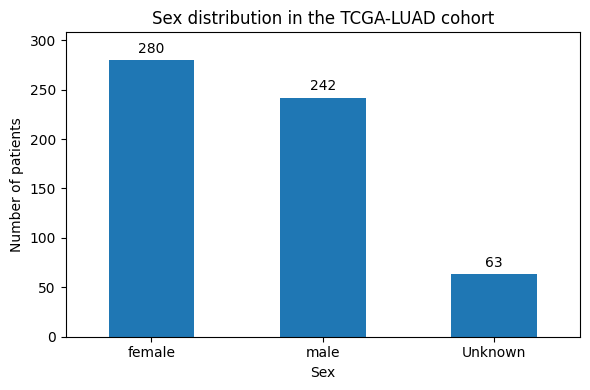

In [7]:
plt.figure(figsize=(6, 4))
ax = sex_counts.plot(kind="bar")

ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.style.use('default')

plt.title("Sex distribution in the TCGA-LUAD cohort")
plt.xlabel("Sex")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
replacements = {"'--": "Unknown"}

plt.tight_layout()
plt.ylim(0, max(sex_counts) * 1.1)
plt.savefig(clinical_plots_dir / "sex_distribution_initial_cohort.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Age distribution

Age at diagnosis is taken from the clinical table.

In [8]:
clinical_plot_df["demographic.age_at_index"] = pd.to_numeric(
    clinical_plot_df["demographic.age_at_index"],
    errors="coerce"
)

clinical_plot_df["demographic.age_at_index"].describe().to_frame("age_at_diagnosis")


,age_at_diagnosis
count,503.000000
mean,65.328032
std,10.019789
min,33.000000
25%,59.000000
50%,66.000000
75%,73.000000
max,88.000000


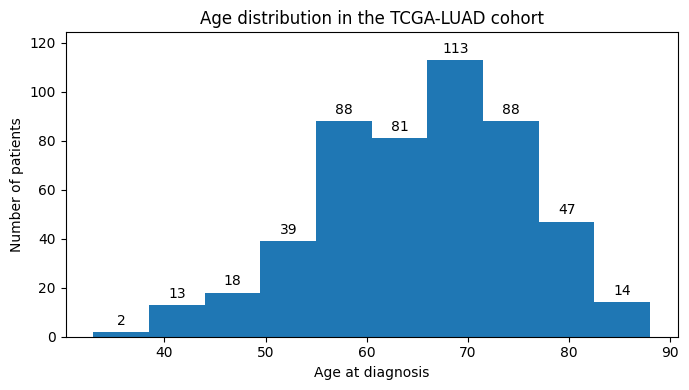

In [9]:
plt.figure(figsize=(7, 4))
counts, bins, patches = plt.hist(clinical_plot_df["demographic.age_at_index"].dropna(), bins=10)

plt.bar_label(patches, labels=[str(int(c)) for c in counts], padding=3)
plt.style.use('default')

plt.title("Age distribution in the TCGA-LUAD cohort")
plt.xlabel("Age at diagnosis")
plt.ylabel("Number of patients")


plt.tight_layout()
plt.ylim(0, max(counts) * 1.1)
plt.savefig(clinical_plots_dir / "age_distribution_initial_cohort.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Smoking-status distribution

Smoking status is taken from the exposure table. Missing, unknown, and not reported values are kept as `Unknown`, so the plot shows how much smoking-status information was unavailable before the final filtering steps.


In [10]:
exposure_plot_df["Smoking_Category"] = exposure_plot_df["exposures.tobacco_smoking_status"].map(map_smoking_label)

smoking_counts = exposure_plot_df["Smoking_Category"].value_counts()
smoking_counts = smoking_counts.reindex(["Never", "Former", "Current", "Unknown"], fill_value=0)

smoking_counts.to_frame("count")


,count
Smoking_Category,
Never,75
Former,311
Current,122
Unknown,14


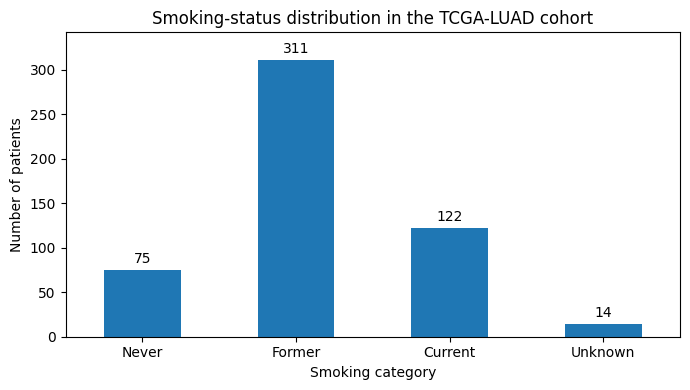

In [11]:
plt.figure(figsize=(7, 4))
ax = smoking_counts.plot(kind="bar")

ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.style.use('default')

plt.title("Smoking-status distribution in the TCGA-LUAD cohort")
plt.xlabel("Smoking category")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.ylim(0, max(smoking_counts) * 1.1)
plt.savefig(clinical_plots_dir / "smoking_status_distribution_initial_cohort.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Basic cohort summary

This summary separates the descriptive initial cohort from the later final analytical cohort.  
The final analytical cohort is created in downstream notebooks after merging clinical, exposure, and mutational-signature data.


In [12]:
basic_cohort_summary = pd.DataFrame({
    "measure": [
        "clinical patients with valid ID",
        "exposure patients with valid ID",
        "patients with age available",
        "patients with sex available",
        "patients with smoking status Never/Former/Current",
        "patients with Unknown smoking status",
    ],
    "count": [
        clinical_plot_df["cases.submitter_id"].nunique(),
        exposure_plot_df["cases.submitter_id"].nunique(),
        clinical_plot_df["demographic.age_at_index"].notna().sum(),
        clinical_plot_df["demographic.gender"].notna().sum(),
        smoking_counts[["Never", "Former", "Current"]].sum(),
        smoking_counts["Unknown"],
    ],
})

basic_cohort_summary


,measure,count
0,clinical patients with valid ID,585
1,exposure patients with valid ID,522
2,patients with age available,503
3,patients with sex available,585
4,patients with smoking status Never/Former/Current,508
5,patients with Unknown smoking status,14


## 9. Saved plot files

In [13]:
saved_files = [
    clinical_plots_dir / "sex_distribution_initial_cohort.png",
    clinical_plots_dir / "age_distribution_initial_cohort.png",
    clinical_plots_dir / "smoking_status_distribution_initial_cohort.png",
]

for path in saved_files:
    print(f'Plot "{path.name}" saved in {path}')
    print()


Plot "sex_distribution_initial_cohort.png" saved in /Users/michaljendrusak/PycharmProjects/tcga-luad-smoking-mutational-signatures/plots/clinical_distributions/sex_distribution_initial_cohort.png

Plot "age_distribution_initial_cohort.png" saved in /Users/michaljendrusak/PycharmProjects/tcga-luad-smoking-mutational-signatures/plots/clinical_distributions/age_distribution_initial_cohort.png

Plot "smoking_status_distribution_initial_cohort.png" saved in /Users/michaljendrusak/PycharmProjects/tcga-luad-smoking-mutational-signatures/plots/clinical_distributions/smoking_status_distribution_initial_cohort.png

